# YOLO Segmentation Training (Kaggle)

This notebook trains a single-class YOLO segmentation model and exports `best.pt`.

In [2]:
from pathlib import Path

print('Kaggle working dir:', Path('/kaggle/working'))
print('Kaggle input dir:', Path('/kaggle/input'))

Kaggle working dir: /kaggle/working
Kaggle input dir: /kaggle/input


In [3]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[

In [4]:
from pathlib import Path

yaml_files = list(Path('/kaggle/input').rglob('*.yaml'))
print('Found YAML files:')
for f in yaml_files:
    print(f)

Found YAML files:
/kaggle/input/notebooks/deepakat002/yolov11-segmentation-butterfly/dataset.yaml
/kaggle/input/notebooks/deepakat002/yolov11-segmentation-butterfly/training_backup/butterfly/args.yaml


In [5]:
data_yaml_path = '/kaggle/input/notebooks/deepakat002/yolov11-segmentation-butterfly/dataset.yaml'
yaml_path = Path(data_yaml_path)
print('Using YAML:', yaml_path)
print('Exists:', yaml_path.exists())
assert yaml_path.exists(), f'YAML not found: {yaml_path}'

Using YAML: /kaggle/input/notebooks/deepakat002/yolov11-segmentation-butterfly/dataset.yaml
Exists: True


In [6]:
import yaml

with open(data_yaml_path, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

print('Dataset keys:', sorted(data_cfg.keys()))
print('nc:', data_cfg.get('nc'))
print('names:', data_cfg.get('names'))

Dataset keys: ['names', 'nc', 'train', 'val']
nc: 1
names: ['butterfly']


In [7]:
dataset_root = yaml_path.parent

def _resolve_images_path(path_value: str, split_name: str) -> Path:
    p = Path(path_value)

    # 1) if already valid, keep as-is
    if p.exists():
        return p.resolve()

    # 2) if path has 'yolov11_split', remap tail under dataset_root
    parts = list(p.parts)
    if 'yolov11_split' in parts:
        idx = parts.index('yolov11_split')
        tail = Path(*parts[idx:])
        candidate = (dataset_root / tail).resolve()
        if candidate.exists():
            return candidate

    # 3) explicit default expected layout
    default_candidate = (dataset_root / f'yolov11_split/{split_name}/images').resolve()
    if default_candidate.exists():
        return default_candidate

    # 4) last-resort recursive search
    matches = list(dataset_root.rglob(f'{split_name}/images'))
    if matches:
        return matches[0].resolve()

    raise FileNotFoundError(f'Could not resolve images path for split={split_name}, original={path_value}')

train_images_dir = _resolve_images_path(str(data_cfg['train']), 'train')
val_images_dir = _resolve_images_path(str(data_cfg['val']), 'val')

fixed_cfg = dict(data_cfg)
fixed_cfg['train'] = str(train_images_dir)
fixed_cfg['val'] = str(val_images_dir)

fixed_yaml_path = '/kaggle/working/dataset_fixed.yaml'
with open(fixed_yaml_path, 'w', encoding='utf-8') as f:
    yaml.safe_dump(fixed_cfg, f, sort_keys=False)

print('Using fixed yaml:', fixed_yaml_path)
print('Train images dir:', train_images_dir)
print('Val images dir:', val_images_dir)
print('Train exists:', train_images_dir.exists())
print('Val exists:', val_images_dir.exists())

assert train_images_dir.exists(), 'Train images path does not exist after fixing.'
assert val_images_dir.exists(), 'Val images path does not exist after fixing.'

Using fixed yaml: /kaggle/working/dataset_fixed.yaml
Train images dir: /kaggle/input/notebooks/deepakat002/yolov11-segmentation-butterfly/yolov11_split/train/images
Val images dir: /kaggle/input/notebooks/deepakat002/yolov11-segmentation-butterfly/yolov11_split/val/images
Train exists: True
Val exists: True


In [8]:
def image_to_label_path(image_path: Path) -> Path:
    # image: .../train/images/foo.jpg
    # label: .../train/labels/foo.txt
    return image_path.parent.parent / "labels" / f"{image_path.stem}.txt"

all_train_images = sorted(
    [p for p in train_images_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
)

print("Total train images found:", len(all_train_images))

# quick check size (change to full check by removing [:50])
sample_train_images = all_train_images
print("Checked sample images:", len(sample_train_images))

Total train images found: 240
Checked sample images: 240


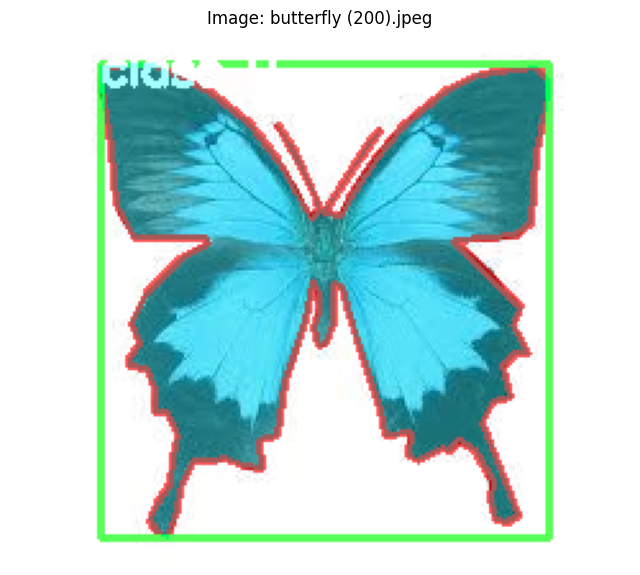

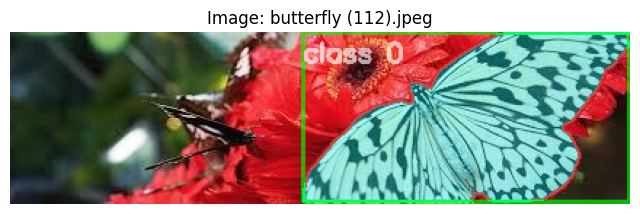

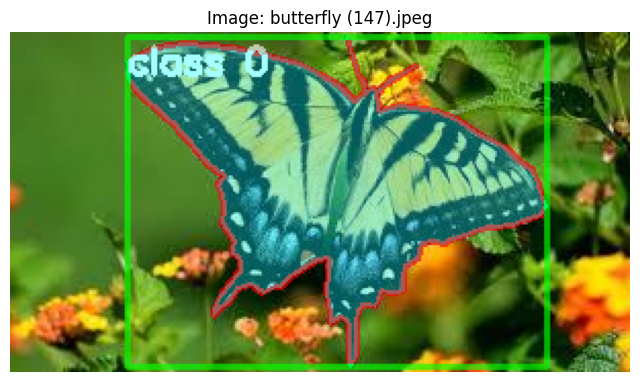

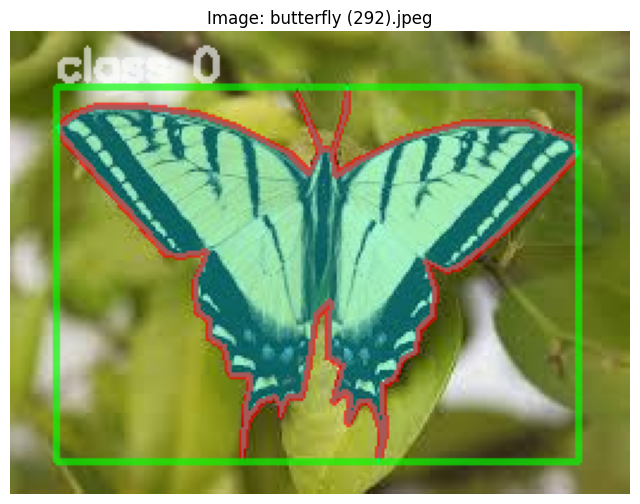

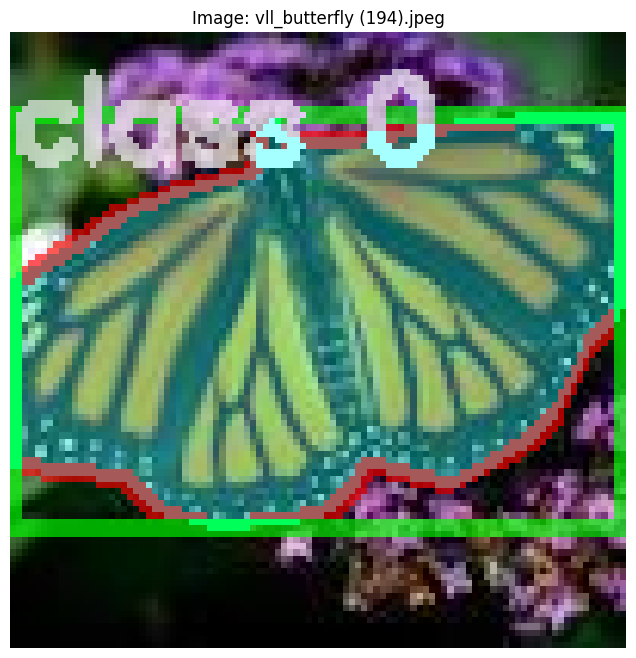

In [9]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def image_to_label_path(image_path: Path) -> Path:
    return image_path.parent.parent / "labels" / f"{image_path.stem}.txt"

def draw_segmentation_example(image_path: Path):
    label_path = image_to_label_path(image_path)

    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    overlay = img.copy()

    if label_path.exists():
        lines = [ln.strip() for ln in label_path.read_text(encoding="utf-8").splitlines() if ln.strip()]
        for line in lines:
            vals = line.split()
            cls_id = int(float(vals[0]))
            coords = list(map(float, vals[1:]))

            # normalized xy -> pixel xy
            pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
            pts_int = pts.astype(np.int32)

            cv2.fillPoly(overlay, [pts_int], color=(0, 255, 255))
            cv2.polylines(img, [pts_int], isClosed=True, color=(255, 0, 0), thickness=2)

            x_min, y_min = pts_int[:, 0].min(), pts_int[:, 1].min()
            x_max, y_max = pts_int[:, 0].max(), pts_int[:, 1].max()
            cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
            cv2.putText(img, f"class {cls_id}", (x_min, max(20, y_min-8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    vis = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)

    plt.figure(figsize=(8, 8))
    plt.imshow(vis)
    plt.title(f"Image: {image_path.name}")
    plt.axis("off")
    plt.show()

# show 5 random samples
for p in random.sample(all_train_images, 5):
    draw_segmentation_example(p)

In [10]:
import torch
from ultralytics import YOLO

use_gpu = False
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    use_gpu = major >= 7  # require sm_70+

device = "cuda" if use_gpu else "cpu"
print("Training device:", device)

model = YOLO("yolov8n-seg.pt")
train_results = model.train(
    data=fixed_yaml_path,
    epochs=40 if device == "cuda" else 15,
    imgsz=640 if device == "cuda" else 512,
    batch=16 if device == "cuda" else 4,
    patience=10,
    project="/kaggle/working/runs",
    name="seg_demo",
    device=device
)
train_results

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


Training device: cpu
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_fixed.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seg_demo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78b800a7bb90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [12]:
best_model_path = Path('/kaggle/working/runs/seg_demo-2/weights/best.pt')
print('best.pt exists:', best_model_path.exists())
print('best.pt path:', best_model_path)


best.pt exists: False
best.pt path: /kaggle/working/runs/seg_demo-2/weights/best.pt
